In [ ]:
from google.colab import drive
import os
import shutil
import kagglehub

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Download dataset from Kaggle
print("Downloading dataset from Kaggle...")
os.environ["KAGGLEHUB_VERIFY_SSL"] = "0"
temp_path = kagglehub.dataset_download("andrewmvd/medical-mnist")
print("Downloaded to temporary path:", temp_path)

# 3. Define the destination path in Google Drive
DRIVE_DATA_DIR = '/content/drive/MyDrive/medical-mnist'

# 4. Upload/Move dataset to Google Drive if it doesn't exist
if not os.path.exists(DRIVE_DATA_DIR):
    print(f"Moving dataset to Google Drive: {DRIVE_DATA_DIR}...")
    shutil.copytree(temp_path, DRIVE_DATA_DIR)
    print("Dataset successfully uploaded to Google Drive.")
else:
    print(f"Dataset already exists in Google Drive at {DRIVE_DATA_DIR}.")

!pip install tensorflow matplotlib numpy seaborn scikit-learn

Mounted at /content/drive
Using Colab cache for faster access to the 'medical-mnist' dataset.
Downloaded to temporary path: /kaggle/input/medical-mnist
Moving dataset to Google Drive: /content/drive/MyDrive/medical-mnist...
Dataset successfully uploaded to Google Drive.


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required libraries
!pip install tensorflow matplotlib numpy seaborn scikit-learn kagglehub

Mounted at /content/drive


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required libraries
!pip install tensorflow matplotlib numpy seaborn scikit-learn kagglehub

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import tensorflow as tf

IMG_SIZE = 64
BATCH_SIZE = 32
DATA_DIR = '/content/drive/MyDrive/medical-mnist'

In [5]:
import tensorflow as tf

IMG_SIZE = 64
BATCH_SIZE = 32
DATA_DIR = '/content/drive/MyDrive/medical-mnist'

raw_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    label_mode=None,   # better than labels=None
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 15943 files.


In [6]:
def format_dataset(x):
    x = tf.cast(x, tf.float32) / 255.0
    return x, x

train_dataset = raw_dataset.map(format_dataset)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

In [8]:
from tensorflow.keras import layers, Model

def build_autoencoder():
    inputs = layers.Input(shape=(64, 64, 3))

    # Encoder
    x = layers.Conv2D(32, 3, strides=2, activation='relu', padding='same')(inputs)
    x = layers.Conv2D(64, 3, strides=2, activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    latent = layers.Dense(128, name="latent")(x)

    # Decoder
    x = layers.Dense(16*16*64, activation='relu')(latent)
    x = layers.Reshape((16, 16, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)

    outputs = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

    return Model(inputs, outputs)

ae = build_autoencoder()
ae.compile(optimizer='adam', loss='mse')

In [9]:
history_ae = ae.fit(
    train_dataset,
    epochs=7
)

Epoch 1/7
499/499 ━━━━━━━━━━━━━━━━━━━━ 1091s 2s/step - loss: 0.0135
Epoch 2/7
499/499 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - loss: 0.0051
Epoch 3/7
499/499 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - loss: 0.0035
Epoch 4/7
499/499 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - loss: 0.0028
Epoch 5/7
499/499 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - loss: 0.0024
Epoch 6/7
499/499 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - loss: 0.0021
Epoch 7/7
499/499 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - loss: 0.0019


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


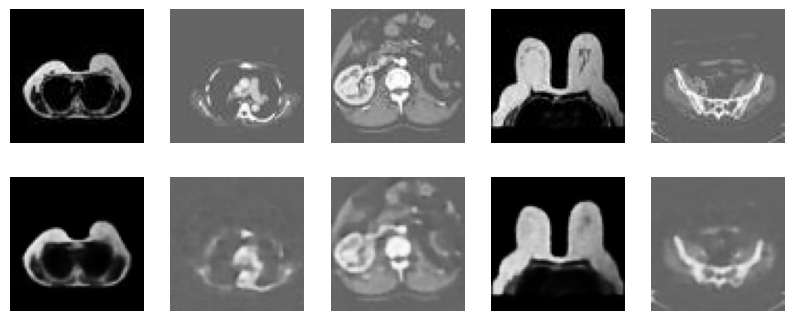

In [11]:
import matplotlib.pyplot as plt

def show_reconstruction(model, dataset):
    for batch_x, _ in dataset.take(1):
        reconstructed = model.predict(batch_x)

        plt.figure(figsize=(10,4))

        for i in range(5):
            # Original
            plt.subplot(2,5,i+1)
            plt.imshow(batch_x[i])
            plt.axis('off')

            # Reconstructed
            plt.subplot(2,5,i+6)
            plt.imshow(reconstructed[i])
            plt.axis('off')

        plt.show()

show_reconstruction(ae, train_dataset)

In [12]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [13]:
from tensorflow.keras import layers, Model
import tensorflow as tf

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


class VAE(Model):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder_conv1 = layers.Conv2D(32, 3, strides=2, activation='relu', padding='same')
        self.encoder_conv2 = layers.Conv2D(64, 3, strides=2, activation='relu', padding='same')
        self.flatten = layers.Flatten()

        self.z_mean = layers.Dense(128)
        self.z_log_var = layers.Dense(128)
        self.sampling = Sampling()

        # Decoder
        self.dense = layers.Dense(16*16*64, activation='relu')
        self.reshape = layers.Reshape((16,16,64))
        self.deconv1 = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')
        self.deconv2 = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')
        self.output_layer = layers.Conv2D(3, 3, activation='sigmoid', padding='same')

    def call(self, inputs):
        # Encoder
        x = self.encoder_conv1(inputs)
        x = self.encoder_conv2(x)
        x = self.flatten(x)

        z_mean = self.z_mean(x)
        z_log_var = self.z_log_var(x)

        z = self.sampling([z_mean, z_log_var])

        # Decoder
        x = self.dense(z)
        x = self.reshape(x)
        x = self.deconv1(x)
        x = self.deconv2(x)
        reconstruction = self.output_layer(x)


        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )

        self.add_loss(kl_loss)

        return reconstruction

In [14]:
vae = VAE()
vae.compile(optimizer='adam', loss='mse')

history_vae = vae.fit(
    train_dataset,
    epochs=7
)

Epoch 1/7
499/499 ━━━━━━━━━━━━━━━━━━━━ 51s 92ms/step - loss: 0.0351
Epoch 2/7
499/499 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - loss: 0.0314
Epoch 3/7
499/499 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - loss: 0.0286
Epoch 4/7
499/499 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - loss: 0.0257
Epoch 5/7
499/499 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - loss: 0.0253
Epoch 6/7
499/499 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - loss: 0.0252
Epoch 7/7
499/499 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - loss: 0.0250


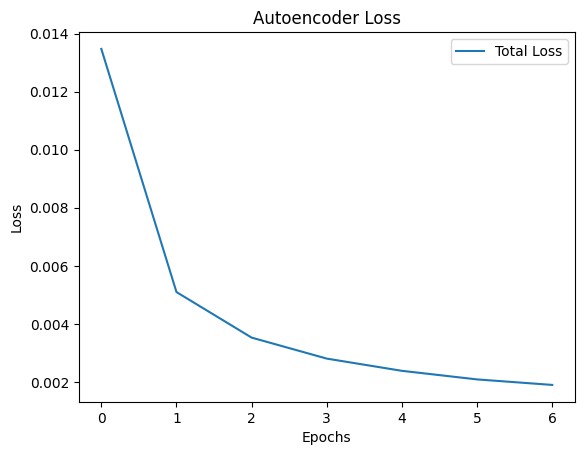

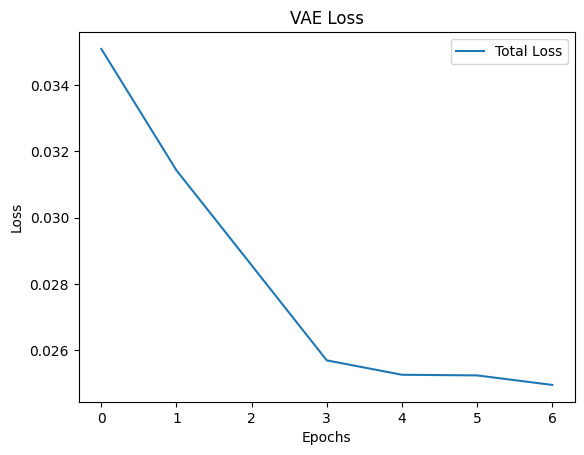

In [15]:
import matplotlib.pyplot as plt

def plot_loss(history, title):
    plt.figure()
    plt.plot(history.history['loss'], label='Total Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# AE loss
plot_loss(history_ae, "Autoencoder Loss")

# VAE loss
plot_loss(history_vae, "VAE Loss")

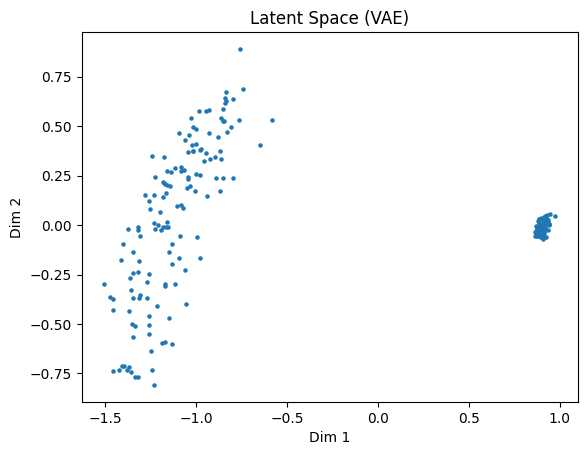

In [16]:
from sklearn.decomposition import PCA
import numpy as np

def get_latent_vectors(model, dataset, num_batches=10):
    latents = []

    for batch_x, _ in dataset.take(num_batches):
        # Encoder part only
        x = model.encoder_conv1(batch_x)
        x = model.encoder_conv2(x)
        x = model.flatten(x)
        z_mean = model.z_mean(x)

        latents.append(z_mean.numpy())

    return np.vstack(latents)

latent_vectors = get_latent_vectors(vae, train_dataset)

# Reduce to 2D
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_vectors)

# Plot
plt.figure()
plt.scatter(latent_2d[:,0], latent_2d[:,1], s=5)
plt.title("Latent Space (VAE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

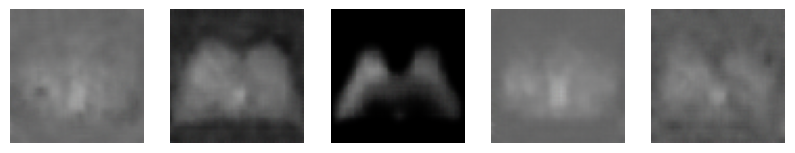

In [17]:
def generate_samples(model, num_samples=5):
    z = tf.random.normal(shape=(num_samples, 128))
    generated = model.dense(z)
    generated = model.reshape(generated)
    generated = model.deconv1(generated)
    generated = model.deconv2(generated)
    generated = model.output_layer(generated)

    plt.figure(figsize=(10,2))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(generated[i])
        plt.axis('off')
    plt.show()

generate_samples(vae)

In [21]:
def add_noise(images):
    noise = tf.random.normal(shape=tf.shape(images), mean=0.0, stddev=0.1)
    noisy = images + noise
    return tf.clip_by_value(noisy, 0.0, 1.0)

def format_noisy_dataset(x):
    x = tf.cast(x, tf.float32) / 255.0
    noisy_x = add_noise(x)
    return noisy_x, x

noisy_dataset = raw_dataset.map(format_noisy_dataset).prefetch(tf.data.AUTOTUNE)

# Train AE on noisy data
denoise_ae = build_autoencoder()
denoise_ae.compile(optimizer='adam', loss='mse')

x= denoise_ae.fit(noisy_dataset, epochs=5)

Epoch 1/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 54s 97ms/step - loss: 0.0152
Epoch 2/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 44s 88ms/step - loss: 0.0073
Epoch 3/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 80s 86ms/step - loss: 0.0050
Epoch 4/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 44s 88ms/step - loss: 0.0039
Epoch 5/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - loss: 0.0032


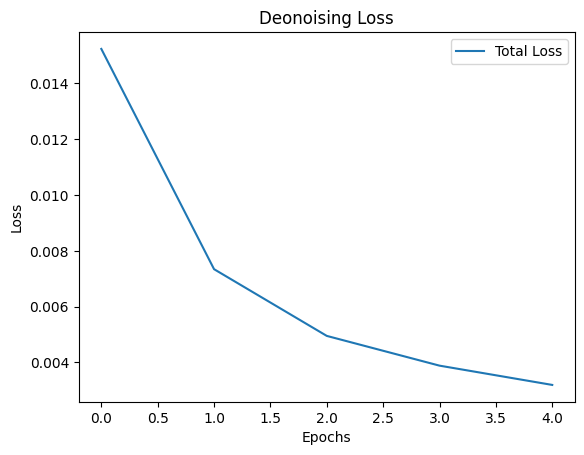

In [22]:
plot_loss(x, "Deonoising Loss")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 993ms/step


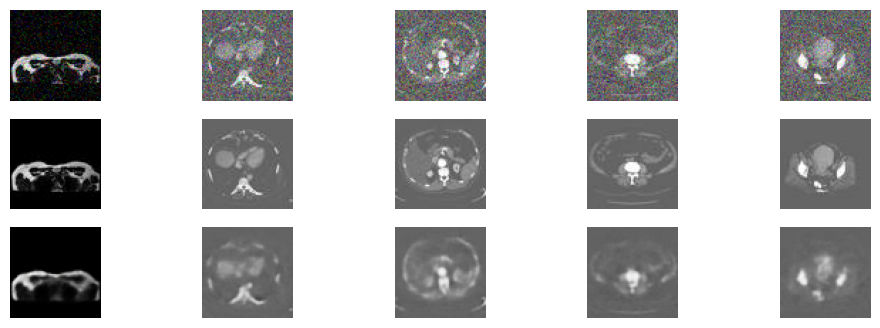

In [19]:
def show_denoising(model, dataset):
    for noisy_x, clean_x in dataset.take(1):
        reconstructed = model.predict(noisy_x)

        plt.figure(figsize=(12,4))
        for i in range(5):
            # Noisy
            plt.subplot(3,5,i+1)
            plt.imshow(noisy_x[i])
            plt.axis('off')

            # Clean
            plt.subplot(3,5,i+6)
            plt.imshow(clean_x[i])
            plt.axis('off')

            # Output
            plt.subplot(3,5,i+11)
            plt.imshow(reconstructed[i])
            plt.axis('off')

        plt.show()

show_denoising(denoise_ae, noisy_dataset)